In [ ]:
### Environment Setup
#Import all required libraries for data manipulation, visualization, and statistical analysis.
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import ttest_ind, fisher_exact, false_discovery_control

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")

print("Environment ready!")

Environment ready!


In [5]:
## Load Dataset- Load and combine the 3 brand CSV files into a single DataFrame.
# Load all three brand files
nykaa   = pd.read_csv('data/nykaa_campaign_data.csv')
tira    = pd.read_csv('data/tira_campaign_data.csv')
purplle = pd.read_csv('data/purplle_campaign_data.csv')

# Add brand identifier before combining
nykaa['Brand']   = 'Nykaa'
tira['Brand']    = 'Tira'
purplle['Brand'] = 'Purplle'

# Combine into one DataFrame
df = pd.concat([nykaa, tira, purplle], ignore_index=True)

print(f"Nykaa rows   : {len(nykaa):,}")
print(f"Tira rows    : {len(tira):,}")
print(f"Purplle rows : {len(purplle):,}")
print(f"Combined rows: {len(df):,}")


Nykaa rows   : 55,555
Tira rows    : 55,555
Purplle rows : 55,555
Combined rows: 166,665


In [6]:
## Explore Data Structure - Examine columns, data types, and first few rows.
# Basic info
print("SHAPE:", df.shape)
print("\nCOLUMNS:", df.columns.tolist())
print("\nDATA TYPES:\n", df.dtypes)
print("\nFIRST 5 ROWS:")
df.head()

SHAPE: (166665, 17)

COLUMNS: ['Campaign_ID', 'Campaign_Type', 'Target_Audience', 'Duration', 'Channel_Used', 'Impressions', 'Clicks', 'Leads', 'Conversions', 'Revenue', 'Acquisition_Cost', 'ROI', 'Language', 'Engagement_Score', 'Customer_Segment', 'Date', 'Brand']

DATA TYPES:
 Campaign_ID             str
Campaign_Type           str
Target_Audience         str
Duration              int64
Channel_Used            str
Impressions           int64
Clicks                int64
Leads                 int64
Conversions           int64
Revenue               int64
Acquisition_Cost    float64
ROI                 float64
Language                str
Engagement_Score    float64
Customer_Segment        str
Date                    str
Brand                   str
dtype: object

FIRST 5 ROWS:


,Campaign_ID,Campaign_Type,Target_Audience,Duration,Channel_Used,Impressions,Clicks,Leads,Conversions,Revenue,Acquisition_Cost,ROI,Language,Engagement_Score,Customer_Segment,Date,Brand
0,NY-CMP-1000,Social Media,College Students,21,"WhatsApp, YouTube",57804,6156,3616,2355,1867515,111.03,6.14,Hindi,20.98,College Students,29-04-2025,Nykaa
1,NY-CMP-1001,Paid Ads,Tier 2 City Customers,18,YouTube,91801,3321,1971,1357,1046247,180.83,3.26,Hindi,7.24,College Students,06-04-2025,Nykaa
2,NY-CMP-1002,Influencer,Youth,23,"WhatsApp, Google, YouTube",15536,2182,952,755,197055,90.60,1.88,English,25.03,College Students,14-01-2025,Nykaa
3,NY-CMP-1003,Email,Working Women,18,"YouTube, Facebook, Instagram",88114,8413,2231,947,376906,249.07,0.60,Hindi,13.15,College Students,04-06-2025,Nykaa
4,NY-CMP-1004,Paid Ads,College Students,10,"Facebook, Instagram",96871,3743,2060,1258,518296,228.60,0.80,Hindi,7.29,Tier 2 City Customers,29-12-2024,Nykaa


In [7]:
## Grouping Variable Analysis- Identify and examine the primary grouping variable for channel comparison.
# Primary grouping variable - Campaign Type
print("PRIMARY GROUPING VARIABLE: Campaign_Type")
print(f"Number of distinct groups: {df['Campaign_Type'].nunique()}")
print("\nGroups and sample sizes:")
print(df['Campaign_Type'].value_counts())

# Secondary grouping variables available
print("\nSECONDARY GROUPING VARIABLES:")
print(f"  Brands          : {df['Brand'].nunique()} -> {df['Brand'].unique().tolist()}")
print(f"  Target Audiences: {df['Target_Audience'].nunique()} -> {df['Target_Audience'].unique().tolist()}")
print(f"  Languages       : {df['Language'].nunique()} -> {df['Language'].unique().tolist()}")

PRIMARY GROUPING VARIABLE: Campaign_Type
Number of distinct groups: 5

Groups and sample sizes:
Campaign_Type
Influencer      33503
Email           33493
Paid Ads        33283
SEO             33207
Social Media    33179
Name: count, dtype: int64

SECONDARY GROUPING VARIABLES:
  Brands          : 3 -> ['Nykaa', 'Tira', 'Purplle']
  Target Audiences: 5 -> ['College Students', 'Tier 2 City Customers', 'Youth', 'Working Women', 'Premium Shoppers']
  Languages       : 4 -> ['Hindi', 'English', 'Tamil', 'Bengali']


In [8]:
 ## Performance Metrics Available - Identify which metrics exist in the raw data and which need to be calculated.
# Raw metrics already in the dataset
print("RAW METRICS IN DATASET:")
raw_metrics = ['Impressions', 'Clicks', 'Leads', 'Conversions', 'Revenue', 'Acquisition_Cost', 'ROI']
for metric in raw_metrics:
    print(f"  {metric}: min={df[metric].min():,.2f}  max={df[metric].max():,.2f}  mean={df[metric].mean():,.2f}")

# Metrics we need to calculate
print("\nMETRICS TO CALCULATE:")
print("  CTR           = Clicks / Impressions")
print("  Conv_Rate     = Conversions / Clicks")
print("  CPA           = Acquisition_Cost / Conversions")
print("  ROAS          = Revenue / Acquisition_Cost")
print("  Profit        = Revenue - Acquisition_Cost")
print("  Profit_Margin = Profit / Revenue")

RAW METRICS IN DATASET:
  Impressions: min=10,001.00  max=100,000.00  mean=55,060.85
  Clicks: min=202.00  max=14,944.00  mean=4,682.37
  Leads: min=48.00  max=8,876.00  mean=1,871.51
  Conversions: min=17.00  max=6,686.00  mean=1,029.09
  Revenue: min=3,895.00  max=4,579,910.00  mean=513,906.62
  Acquisition_Cost: min=8.18  max=15,473.16  mean=376.09
  ROI: min=-0.99  max=79.30  mean=2.69

METRICS TO CALCULATE:
  CTR           = Clicks / Impressions
  Conv_Rate     = Conversions / Clicks
  CPA           = Acquisition_Cost / Conversions
  ROAS          = Revenue / Acquisition_Cost
  Profit        = Revenue - Acquisition_Cost
  Profit_Margin = Profit / Revenue


In [9]:
## Data Quality Check - Complete - Check data types, outliers, unusual values, and date formatting.
# 1. Data types check
print("DATA TYPES:")
print(df.dtypes)

# 2. Fix date column to datetime
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
print(f"\nDate range: {df['Date'].min().date()} to {df['Date'].max().date()}")
print(f"Span: {(df['Date'].max() - df['Date'].min()).days} days")

# 3. Outliers - check numeric columns
print("\nNUMERIC SUMMARY (check for unusual values):")
print(df[['Impressions', 'Clicks', 'Conversions', 'Revenue', 'Acquisition_Cost', 'ROI']].describe().round(2))

# 4. Sanity checks - logical relationships
print("\nSANITY CHECKS:")
print(f"  Clicks > Impressions (impossible) : {(df['Clicks'] > df['Impressions']).sum()}")
print(f"  Conversions > Clicks (impossible) : {(df['Conversions'] > df['Clicks']).sum()}")
print(f"  Negative Revenue                  : {(df['Revenue'] < 0).sum()}")
print(f"  Negative Acquisition_Cost         : {(df['Acquisition_Cost'] < 0).sum()}")

DATA TYPES:
Campaign_ID             str
Campaign_Type           str
Target_Audience         str
Duration              int64
Channel_Used            str
Impressions           int64
Clicks                int64
Leads                 int64
Conversions           int64
Revenue               int64
Acquisition_Cost    float64
ROI                 float64
Language                str
Engagement_Score    float64
Customer_Segment        str
Date                    str
Brand                   str
dtype: object

Date range: 2024-07-01 to 2025-06-24
Span: 358 days

NUMERIC SUMMARY (check for unusual values):
       Impressions     Clicks  Conversions     Revenue  Acquisition_Cost  \
count    166665.00  166665.00    166665.00   166665.00         166665.00   
mean      55060.85    4682.37      1029.09   513906.62            376.09   
std       25970.65    3176.50       858.01   487644.25            534.94   
min       10001.00     202.00        17.00     3895.00              8.18   
25%       32566.00  

In [10]:
## Outlier Notes - Key observations noted for statistical caveats in final reporting.
print("OUTLIER SUMMARY:")
print(f"  Acquisition_Cost: mean=${df['Acquisition_Cost'].mean():,.2f}, max=${df['Acquisition_Cost'].max():,.2f}")
print(f"  Revenue         : mean=${df['Revenue'].mean():,.2f}, max=${df['Revenue'].max():,.2f}")
print(f"  ROI             : min={df['ROI'].min():.2f}, max={df['ROI'].max():.2f}")
print("""
NOTE: Outliers exist but will not be removed because:
  - No impossible values detected in sanity checks
  - Large sample size (33,000+ per channel) minimizes outlier impact
  - Variability reflects real campaign performance differences
  - Will be noted as caveats in executive memo
""")

OUTLIER SUMMARY:
  Acquisition_Cost: mean=$376.09, max=$15,473.16
  Revenue         : mean=$513,906.62, max=$4,579,910.00
  ROI             : min=-0.99, max=79.30

NOTE: Outliers exist but will not be removed because:
  - No impossible values detected in sanity checks
  - Large sample size (33,000+ per channel) minimizes outlier impact
  - Variability reflects real campaign performance differences
  - Will be noted as caveats in executive memo



In [11]:
## Save Cleaned Dataset & Final Summary - Document all transformations made, print summary statistics, and save to CSV.
# Calculate derived metrics
df['CTR'] = df['Clicks'] / df['Impressions']
df['Conv_Rate'] = df['Conversions'] / df['Clicks']
df['CPA'] = (df['Acquisition_Cost'] / df['Conversions']).replace([np.inf, -np.inf], np.nan)
df['ROAS'] = (df['Revenue'] / df['Acquisition_Cost']).replace([np.inf, -np.inf], np.nan)
df['Profit'] = df['Revenue'] - df['Acquisition_Cost']
df['Profit_Margin'] = (df['Profit'] / df['Revenue']).replace([np.inf, -np.inf], np.nan)

# Document transformations
print("TRANSFORMATIONS APPLIED:")
print("  1. Added 'Brand' column to each file before combining")
print("  2. Combined 3 brand files into single DataFrame")
print("  3. Converted 'Date' column from string to datetime")
print("  4. Calculated 6 derived metrics:")
print("       CTR           = Clicks / Impressions")
print("       Conv_Rate     = Conversions / Clicks")
print("       CPA           = Acquisition_Cost / Conversions")
print("       ROAS          = Revenue / Acquisition_Cost")
print("       Profit        = Revenue - Acquisition_Cost")
print("       Profit_Margin = Profit / Revenue")

# Summary statistics
print("\nFINAL DATASET SUMMARY:")
print(f"  Total rows       : {len(df):,}")
print(f"  Total columns    : {df.shape[1]}")
print(f"  Date range       : {df['Date'].min().date()} to {df['Date'].max().date()}")
print(f"  Span             : {(df['Date'].max() - df['Date'].min()).days} days")

print(f"\n  Groups (Campaign_Type) - Primary grouping variable:")
print(df['Campaign_Type'].value_counts().to_string())

print(f"\n  Groups (Brand) - Secondary grouping variable:")
print(df['Brand'].value_counts().to_string())

print(f"\n  Groups (Target_Audience) - Secondary grouping variable:")
print(df['Target_Audience'].value_counts().to_string())

# Save to CSV
df.to_csv('data/marketing_data.csv', index=False)
print(f"\n✓ Cleaned dataset saved to: data/marketing_data.csv")
print(f"  Final shape: {df.shape}")

TRANSFORMATIONS APPLIED:
  1. Added 'Brand' column to each file before combining
  2. Combined 3 brand files into single DataFrame
  3. Converted 'Date' column from string to datetime
  4. Calculated 6 derived metrics:
       CTR           = Clicks / Impressions
       Conv_Rate     = Conversions / Clicks
       CPA           = Acquisition_Cost / Conversions
       ROAS          = Revenue / Acquisition_Cost
       Profit        = Revenue - Acquisition_Cost
       Profit_Margin = Profit / Revenue

FINAL DATASET SUMMARY:
  Total rows       : 166,665
  Total columns    : 23
  Date range       : 2024-07-01 to 2025-06-24
  Span             : 358 days

  Groups (Campaign_Type) - Primary grouping variable:
Campaign_Type
Influencer      33503
Email           33493
Paid Ads        33283
SEO             33207
Social Media    33179

  Groups (Brand) - Secondary grouping variable:
Brand
Nykaa      55555
Tira       55555
Purplle    55555

  Groups (Target_Audience) - Secondary grouping variable:
Ta

In [12]:
## Step 3: Aggregate Marketing Metrics by Channel - Group data by Campaign Type and calculate key performance metrics.
# Aggregate raw metrics by channel
channel_agg = df.groupby('Campaign_Type').agg(
    Impressions      = ('Impressions', 'sum'),
    Clicks           = ('Clicks', 'sum'),
    Conversions      = ('Conversions', 'sum'),
    Cost             = ('Acquisition_Cost', 'sum'),
    Revenue          = ('Revenue', 'sum')
).reset_index()

# Calculate metrics from aggregated totals
channel_agg['CTR']           = channel_agg['Clicks'] / channel_agg['Impressions']
channel_agg['Conv_Rate']     = channel_agg['Conversions'] / channel_agg['Clicks']
channel_agg['CPA']           = channel_agg['Cost'] / channel_agg['Conversions']
channel_agg['ROAS']          = channel_agg['Revenue'] / channel_agg['Cost']
channel_agg['Profit']        = channel_agg['Revenue'] - channel_agg['Cost']
channel_agg['Profit_Margin'] = channel_agg['Profit'] / channel_agg['Revenue']

# Handle infinite values
channel_agg.replace([np.inf, -np.inf], np.nan, inplace=True)

# Display summary table
print("CHANNEL PERFORMANCE SUMMARY:")
channel_agg.round(2)

CHANNEL PERFORMANCE SUMMARY:


,Campaign_Type,Impressions,Clicks,Conversions,Cost,Revenue,CTR,Conv_Rate,CPA,ROAS,Profit,Profit_Margin
0,Email,1840785851,156471621,34472617,12635065.72,17222575561,0.09,0.22,0.37,1363.08,1.720994e+10,1.0
1,Influencer,1837177162,156531226,34330330,12692186.38,17080750747,0.09,0.22,0.37,1345.77,1.706806e+10,1.0
2,Paid Ads,1838406238,156264327,34351331,12373170.26,17238518867,0.08,0.22,0.36,1393.22,1.722615e+10,1.0
3,SEO,1828167042,154817943,34026853,12581968.28,17005702921,0.08,0.22,0.37,1351.59,1.699312e+10,1.0
4,Social Media,1832180954,156301670,34331968,12399462.69,17102697975,0.09,0.22,0.36,1379.31,1.709030e+10,1.0


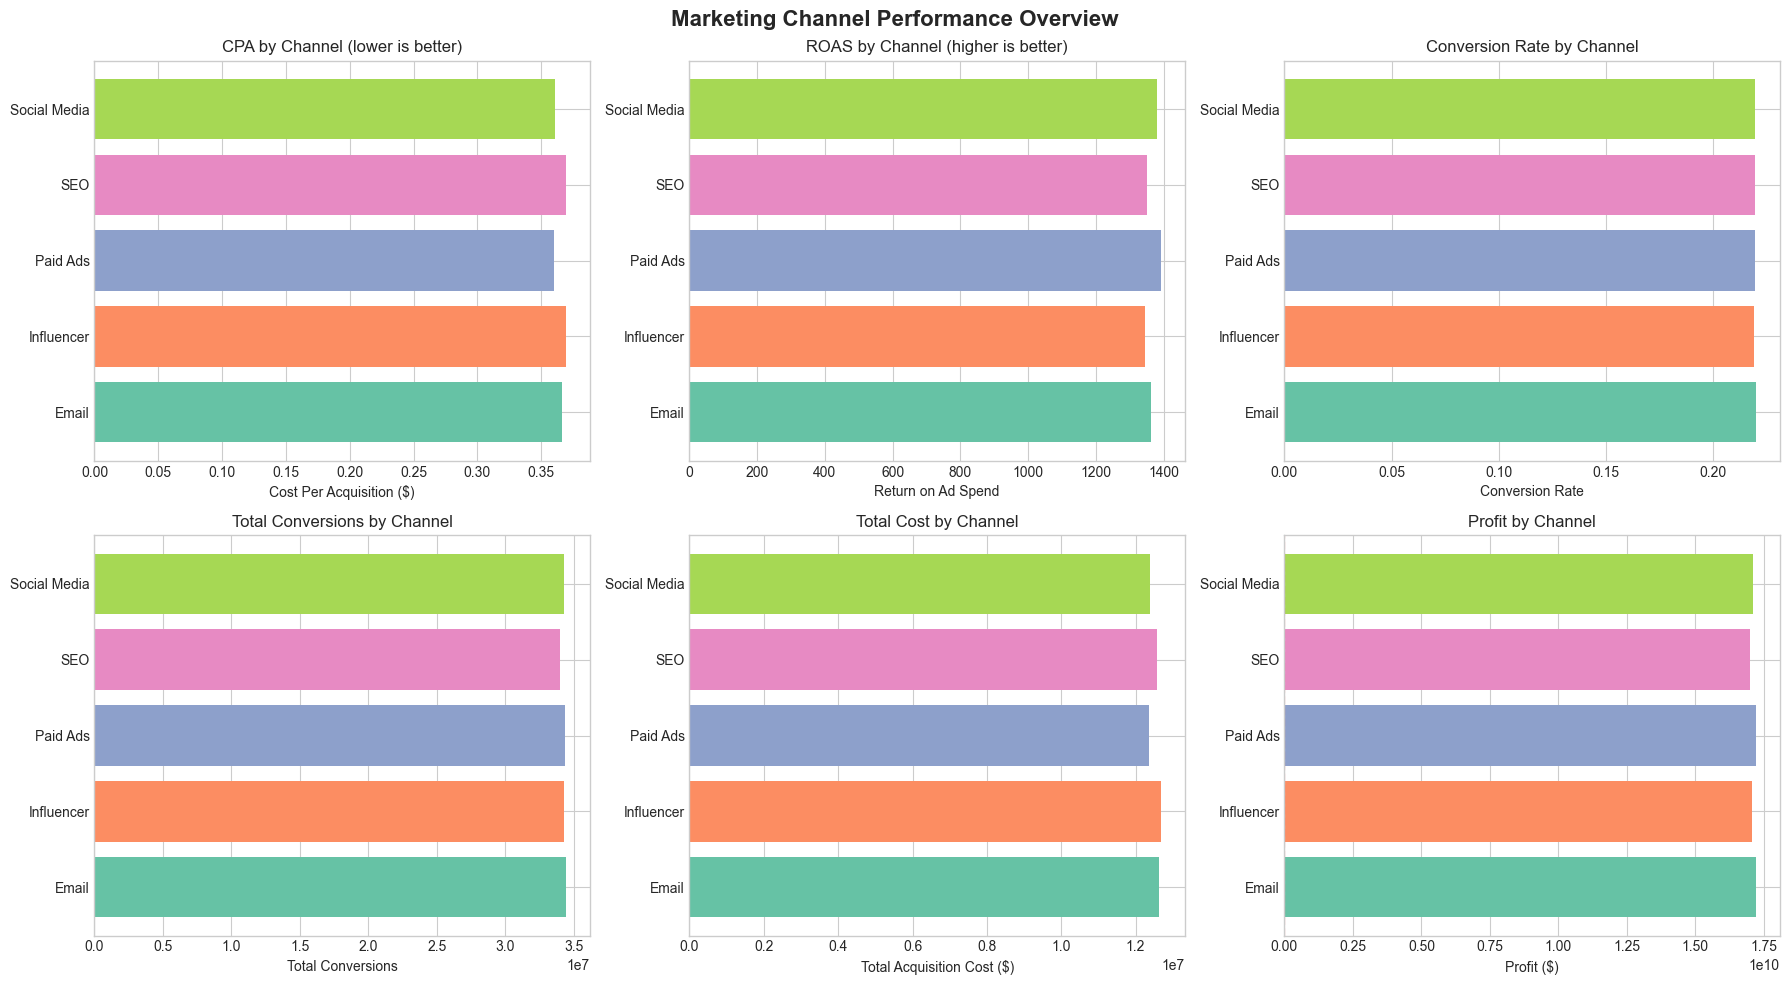

✓ Saved: group_metrics_overview.png


In [14]:
## Visualize Key Metrics by Channel - Horizontal bar charts for CPA, ROAS, Conversion Rate, Total Conversions, Cost and Profit by channel.fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Marketing Channel Performance Overview', fontsize=16, fontweight='bold')

# 1. CPA by channel (lower is better)
axes[0,0].barh(channel_agg['Campaign_Type'], channel_agg['CPA'], color=sns.color_palette("Set2"))
axes[0,0].set_title('CPA by Channel (lower is better)')
axes[0,0].set_xlabel('Cost Per Acquisition ($)')

# 2. ROAS by channel (higher is better)
axes[0,1].barh(channel_agg['Campaign_Type'], channel_agg['ROAS'], color=sns.color_palette("Set2"))
axes[0,1].set_title('ROAS by Channel (higher is better)')
axes[0,1].set_xlabel('Return on Ad Spend')

# 3. Conversion Rate by channel
axes[0,2].barh(channel_agg['Campaign_Type'], channel_agg['Conv_Rate'], color=sns.color_palette("Set2"))
axes[0,2].set_title('Conversion Rate by Channel')
axes[0,2].set_xlabel('Conversion Rate')

# 4. Total Conversions by channel
axes[1,0].barh(channel_agg['Campaign_Type'], channel_agg['Conversions'], color=sns.color_palette("Set2"))
axes[1,0].set_title('Total Conversions by Channel')
axes[1,0].set_xlabel('Total Conversions')

# 5. Total Cost by channel
axes[1,1].barh(channel_agg['Campaign_Type'], channel_agg['Cost'], color=sns.color_palette("Set2"))
axes[1,1].set_title('Total Cost by Channel')
axes[1,1].set_xlabel('Total Acquisition Cost ($)')

# 6. Profit by channel (with vertical line at 0)
axes[1,2].barh(channel_agg['Campaign_Type'], channel_agg['Profit'], color=sns.color_palette("Set2"))
axes[1,2].axvline(x=0, color='red', linewidth=1.5, linestyle='--')
axes[1,2].set_title('Profit by Channel')
axes[1,2].set_xlabel('Profit ($)')

plt.tight_layout()
plt.savefig('group_metrics_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: group_metrics_overview.png")

**Note:** The red zero line on the Profit chart is present but not visible 
because all channels are profitable. The line would only be apparent 
if any channel showed negative profit.

In [15]:
## Distribution Analysis - Examine the spread and variability of key metrics across channels using histograms and box plots.
# Calculate daily metrics (our data has daily granularity)
daily = df.groupby(['Date', 'Campaign_Type']).agg(
    Clicks      = ('Clicks', 'sum'),
    Impressions = ('Impressions', 'sum'),
    Conversions = ('Conversions', 'sum'),
    Cost        = ('Acquisition_Cost', 'sum'),
    Revenue     = ('Revenue', 'sum')
).reset_index()

# Calculate daily metrics
daily['CPA']       = (daily['Cost'] / daily['Conversions']).replace([np.inf, -np.inf], np.nan)
daily['Conv_Rate'] = (daily['Conversions'] / daily['Clicks']).replace([np.inf, -np.inf], np.nan)
daily['ROAS']      = (daily['Revenue'] / daily['Cost']).replace([np.inf, -np.inf], np.nan)

# Drop NaN values
daily.dropna(subset=['CPA', 'Conv_Rate', 'ROAS'], inplace=True)

print(f"Daily records: {len(daily):,}")
print(f"Date range   : {daily['Date'].min().date()} to {daily['Date'].max().date()}")
daily.head()

Daily records: 1,795
Date range   : 2024-07-01 to 2025-06-24


,Date,Campaign_Type,Clicks,Impressions,Conversions,Cost,Revenue,CPA,Conv_Rate,ROAS
0,2024-07-01,Email,369484,4305687,77934,37747.34,41690461,0.484350,0.210927,1104.460897
1,2024-07-01,Influencer,444074,4726846,91044,33379.76,47425751,0.366633,0.205020,1420.793649
2,2024-07-01,Paid Ads,413473,4602393,86665,35607.76,39044241,0.410867,0.209603,1096.509328
3,2024-07-01,SEO,451055,5440946,94603,31705.06,49511932,0.335138,0.209737,1561.641328
4,2024-07-01,Social Media,536548,6154395,118774,30271.53,63299916,0.254867,0.221367,2091.070917


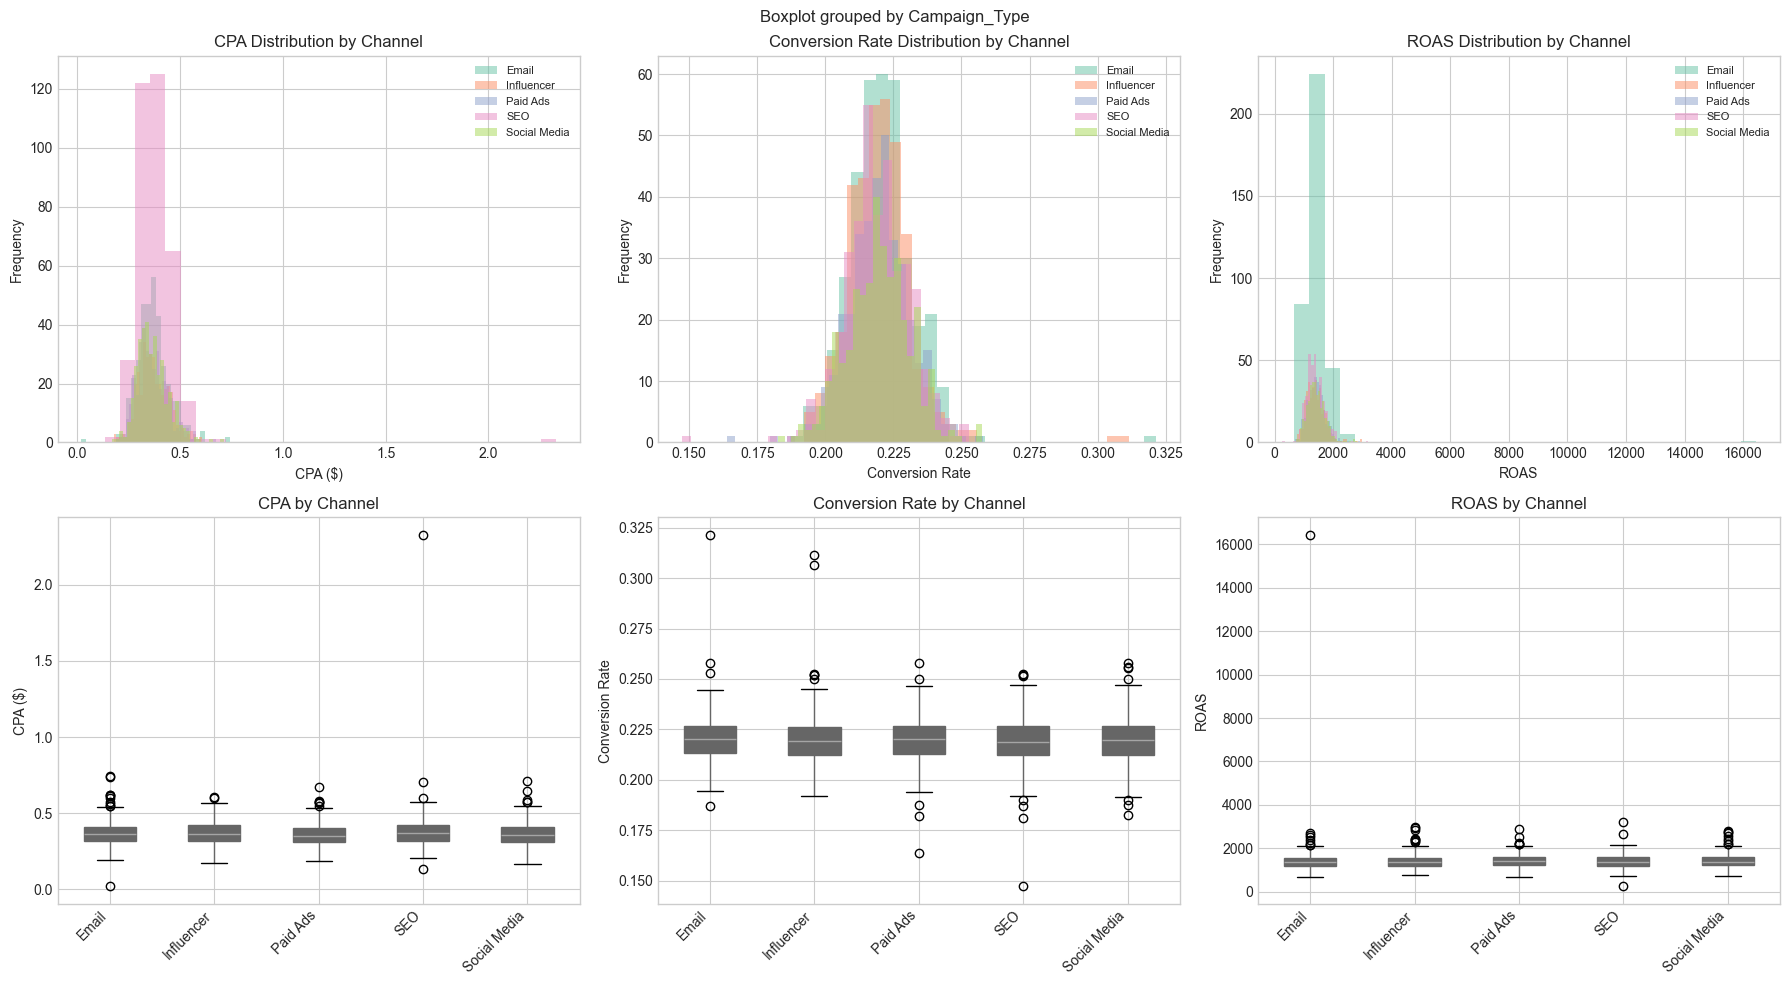

✓ Saved: group_distributions.png


In [16]:
## Distribution Plots - Histograms and Box Plots - Visualize the spread of CPA, Conversion Rate and ROAS across channels.
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Distribution of Key Metrics by Channel', fontsize=16, fontweight='bold')

channels = daily['Campaign_Type'].unique()
colors = sns.color_palette("Set2", len(channels))

# 1. CPA Histogram
for i, channel in enumerate(channels):
    data = daily[daily['Campaign_Type'] == channel]['CPA']
    axes[0,0].hist(data, alpha=0.5, label=channel, color=colors[i], bins=30)
axes[0,0].set_title('CPA Distribution by Channel')
axes[0,0].set_xlabel('CPA ($)')
axes[0,0].set_ylabel('Frequency')
axes[0,0].legend(fontsize=8)

# 2. Conversion Rate Histogram
for i, channel in enumerate(channels):
    data = daily[daily['Campaign_Type'] == channel]['Conv_Rate']
    axes[0,1].hist(data, alpha=0.5, label=channel, color=colors[i], bins=30)
axes[0,1].set_title('Conversion Rate Distribution by Channel')
axes[0,1].set_xlabel('Conversion Rate')
axes[0,1].set_ylabel('Frequency')
axes[0,1].legend(fontsize=8)

# 3. ROAS Histogram
for i, channel in enumerate(channels):
    data = daily[daily['Campaign_Type'] == channel]['ROAS']
    axes[0,2].hist(data, alpha=0.5, label=channel, color=colors[i], bins=30)
axes[0,2].set_title('ROAS Distribution by Channel')
axes[0,2].set_xlabel('ROAS')
axes[0,2].set_ylabel('Frequency')
axes[0,2].legend(fontsize=8)

# 4. CPA Box Plot
daily.boxplot(column='CPA', by='Campaign_Type', ax=axes[1,0], 
              patch_artist=True)
axes[1,0].set_title('CPA by Channel')
axes[1,0].set_xlabel('')
axes[1,0].set_ylabel('CPA ($)')
plt.sca(axes[1,0])
plt.xticks(rotation=45, ha='right')

# 5. Conversion Rate Box Plot
daily.boxplot(column='Conv_Rate', by='Campaign_Type', ax=axes[1,1],
              patch_artist=True)
axes[1,1].set_title('Conversion Rate by Channel')
axes[1,1].set_xlabel('')
axes[1,1].set_ylabel('Conversion Rate')
plt.sca(axes[1,1])
plt.xticks(rotation=45, ha='right')

# 6. ROAS Box Plot
daily.boxplot(column='ROAS', by='Campaign_Type', ax=axes[1,2],
              patch_artist=True)
axes[1,2].set_title('ROAS by Channel')
axes[1,2].set_xlabel('')
axes[1,2].set_ylabel('ROAS')
plt.sca(axes[1,2])
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.savefig('group_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: group_distributions.png")

**Key Observation:** Box plots reveal nearly identical distributions across 
all 5 channels — confirming that visual inspection of aggregate metrics alone 
is insufficient. Statistical testing is essential to determine whether observed 
differences are real or due to chance.